# 03_集成学习-因果推断

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本节，咱们来详细的聊聊**因果推断**\~

简单来说，因果推断就是研究“为什么会发生某件事”的科学方法。它不仅仅关注两个事情是不是相关（相关性），而是想弄明白一个事情发生是否真的导致了另一个事情发生（因果性）。

咱们举个例子：

**相关性**：冰淇淋销量和溺水事件增加往往同时发生。这只是相关，因为夏天热，大家都吃冰淇淋，也更容易去游泳溺水。

**因果性**：吃冰淇淋会不会直接导致溺水？因果推断会告诉我们：不是，冰淇淋本身并不会导致溺水，背后是“天气热”的因素在影响。

所以，因果推断的核心是找出真正“导致”事情发生的因素，而不仅仅是表面上的关联。

**为什么需要因果推断**？

在现实生活中，我们经常想知道做某件事是否会带来效果：

- 吃某种药能不能治病？
- 提高广告预算能不能增加销售？
- 运动能不能让人减肥？

如果只看相关性，容易被误导。因果推断帮助我们做出更科学、更可靠的决策。

**基本思路是**：

1. **提出因果假设**：比如“每天跑步会让体重下降”。
2. **收集数据**：记录每天跑步的人和体重变化。
3. **分析因果关系**：考虑可能的混淆因素，比如饮食习惯、睡眠时间等。
4. **得出结论**：确认跑步本身是否真的能导致体重下降。

咱们举个简单例子，假设你想知道“喝咖啡是否让人更精神”。

- 直接观察：喝咖啡的人更精神。
- 但可能是因为早上爱喝咖啡的人本来就睡得好，更容易精神。
- 因果推断会尝试控制这些干扰因素（比如睡眠时间），最终判断咖啡本身对精神状态有没有影响。

总结来看就是，因果推断就是让我们搞清楚“事情发生的真正原因”，而不是被表面现象骗了眼睛。

## 原理详解

因果推断的核心是量化“干预”对结果的影响，而不是仅仅计算相关性。

数学上，最基础的工具是 **潜在结果框架（Potential Outcomes Framework，又称 Rubin 因果模型）** 和 **结构方程模型（Structural Equation Model, SEM）**。

#### 1. 潜在结果框架

**基本思想**：对于每个个体 $i$，假设有一个二元处理变量 $T$（Treatment, 0 或 1），结果变量为 $Y$。

- 潜在结果 $Y_i(1)$：如果个体 $i$ 接受处理 $T=1$，会得到的结果。
- 潜在结果 $Y_i(0)$：如果个体 $i$ 不接受处理 $T=0$，会得到的结果。

**个体因果效应（Individual Treatment Effect, ITE）**：


$$
\tau_i = Y_i(1) - Y_i(0)
$$


**平均处理效应（Average Treatment Effect, ATE）**：


$$
\text{ATE} = \mathbb{E}[Y(1) - Y(0)]
$$


注意：每个个体只能观测到 $Y_i(1)$ 或 $Y_i(0)$ 中的一种，这就是所谓的“反事实问题（fundamental problem of causal inference）”。

#### 2. 条件独立假设

为了估计 ATE，我们通常假设：


$$
Y(0), Y(1) \perp T \mid X
$$


意思是：在给定协变量 $X$ 的条件下，处理 $T$ 与潜在结果 $Y(0), Y(1)$ 独立。

这保证我们可以通过观察数据估计因果效应。

#### 3. 逆概率加权

假设我们知道接受处理的概率（倾向得分）：


$$
e(X) = P(T=1 \mid X)
$$


ATE 可以通过加权公式估计：


$$
\text{ATE} = \mathbb{E}\left[ \frac{T Y}{e(X)} - \frac{(1-T) Y}{1-e(X)} \right]
$$


思路：给不同概率接受处理的人加权，抵消处理分配的不均衡。

#### 4. 条件平均处理效应

在不同特征条件下的因果效应：


$$
\text{CATE}(X=x) = \mathbb{E}[Y(1) - Y(0) \mid X=x]
$$


CATE 可以帮助分析“不同人群的处理效果不同”。

---

### 因果图与结构方程模型（SEM）

#### 1. 因果图

- 节点：变量（处理 T、结果 Y、协变量 X）
- 有向边：因果关系

示例 DAG：


$$
X \rightarrow T \rightarrow Y
$$


$$
X \rightarrow Y
$$


这里 $X$ 是混淆变量（confounder），同时影响 T 和 Y。

#### 2. do-运算（干预操作）

在 Pearl 的因果推理框架中：


$$
P(Y \mid do(T=1))
$$


与条件概率 $P(Y \mid T=1)$ 不同，do-操作表示我们强制让 $T=1$，阻断外界影响。

**调整公式**：

如果 X 屏蔽了所有“反向路径”，则：


$$
P(Y \mid do(T=1)) = \sum_x P(Y \mid T=1, X=x) P(X=x)
$$


---

### 因果推断的算法流程

#### 1. 数据准备

- 收集处理变量 $T$、结果变量 $Y$、协变量 $X$
- 确定可能的混淆变量

#### 2. 因果假设

- 构建因果图（DAG）
- 确定需要调整的混淆变量

#### 3. 估计倾向得分（Propensity Score）


$$
e(X) = P(T=1 \mid X)
$$


- 用逻辑回归、机器学习模型等估计

#### 4. 因果效应估计

方法包括：

1. **匹配法**

   - 根据倾向得分匹配处理组和对照组
   - 估计 ATE:


$$
\hat{\tau} = \frac{1}{N} \sum_i \left( Y_i^T - Y_i^C \right)
$$


1. **加权法**

   - 使用上面提到的逆概率加权公式
2. **回归调整法**

   - 用回归模型预测 $Y$：


$$
\hat{Y} = \beta_0 + \beta_T T + \beta_X X
$$


- 因果效应由 $\beta_T$ 给出

1. **双重稳健法**

   - 结合倾向得分加权和回归调整，提高鲁棒性

#### 5. 验证假设

- 检查平衡性（matching 或加权后处理组与对照组的协变量分布是否接近）
- 进行敏感性分析（sensitivity analysis）评估未观测混淆的影响

---

### 总结公式体系

这里把刚刚论述的，总结一下：

1. **个体因果效应**：


$$
\tau_i = Y_i(1) - Y_i(0)
$$


1. **平均处理效应**：


$$
\text{ATE} = \mathbb{E}[Y(1) - Y(0)]
$$


1. **条件独立假设**：


$$
Y(0), Y(1) \perp T \mid X
$$


1. **倾向得分加权估计 ATE**：


$$
\text{ATE} = \mathbb{E}\left[ \frac{T Y}{e(X)} - \frac{(1-T) Y}{1-e(X)} \right]
$$


1. **do-操作调整公式**：


$$
P(Y \mid do(T=1)) = \sum_x P(Y \mid T=1, X=x) P(X=x)
$$


1. **CATE**：


$$
\text{CATE}(X=x) = \mathbb{E}[Y(1) - Y(0) \mid X=x]
$$


## 完整案例

咱们利用模拟数据，使用因果推断算法，估计处理变量对结果变量的因果效应，最后进行可视化分析。

数据包含协变量、混淆变量、处理变量和结果变量，设计了真实的因果效应（ATE=3）。

数据前5行:
          X1        X2  Z  T         Y
0  0.496714  4.099033  0  1  4.763934
1 -0.138264  3.386951  0  1  3.703249
2  0.647689  2.089446  0  0  4.230449
3  1.523030  1.029595  0  1  5.290303
4 -0.234153  3.047335  1  1  4.884336


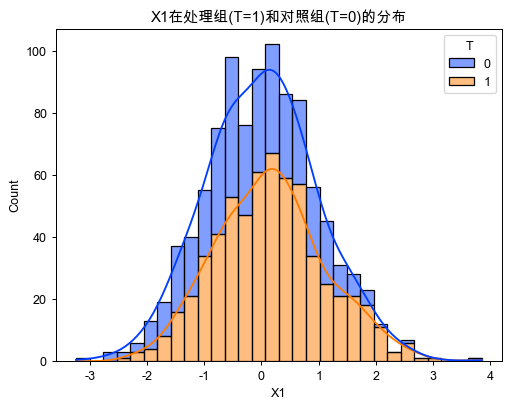

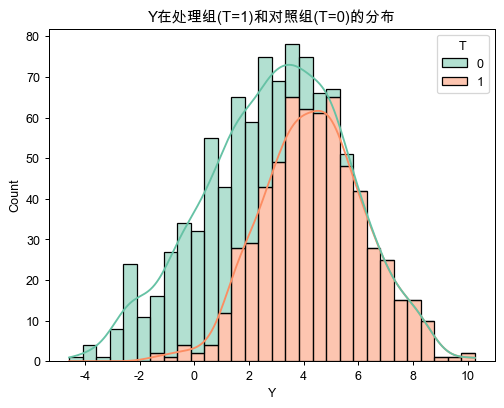

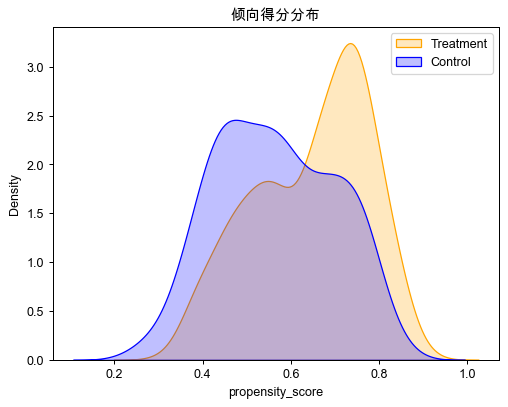

加权法估计的ATE: 2.129


回归调整法估计的ATE: 3.055


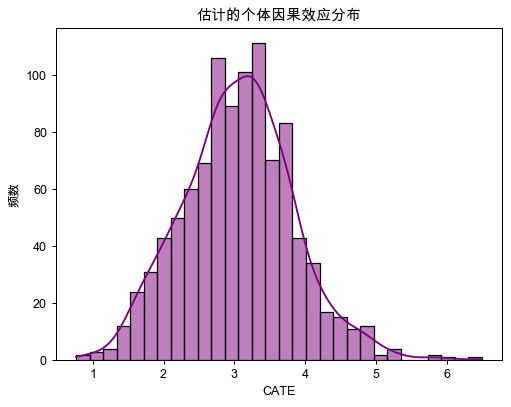

双重稳健法估计的ATE: 3.030


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


# 1，生成模拟数据
np.random.seed(42)
N = 1000  # 样本量
X1 = np.random.normal(0, 1, N)
X2 = np.random.normal(2, 1.5, N)
Z = np.random.binomial(1, 0.5, N)
logit_T = 0.3*X1 + 0.8*Z
p_T = 1/(1+np.exp(-logit_T))
T = np.random.binomial(1, p_T)
Y0 = 2 + 1.5*X1 - 0.5*X2 + 0.5*Z + np.random.normal(0, 1, N)
Y1 = Y0 + 3
Y = T*Y1 + (1-T)*Y0

data = pd.DataFrame({'X1': X1, 'X2': X2, 'Z': Z, 'T': T, 'Y': Y})

# 2，数据探索性分析
print("数据前5行:\n", data.head())

sns.histplot(data=data, x='X1', hue='T', bins=30, palette='bright', kde=True, multiple='stack')
plt.title('X1在处理组(T=1)和对照组(T=0)的分布')
plt.show()

sns.histplot(data=data, x='Y', hue='T', bins=30, palette='Set2', kde=True, multiple='stack')
plt.title('Y在处理组(T=1)和对照组(T=0)的分布')
plt.show()

# 3，倾向得分估计
X_cov = data[['X1', 'X2', 'Z']]
y_treat = data['T']
prop_model = LogisticRegression()
prop_model.fit(X_cov, y_treat)
data['propensity_score'] = prop_model.predict_proba(X_cov)[:,1]

sns.kdeplot(data=data[data['T']==1], x='propensity_score', fill=True, color='orange', label='Treatment')
sns.kdeplot(data=data[data['T']==0], x='propensity_score', fill=True, color='blue', label='Control')
plt.title('倾向得分分布')
plt.legend()
plt.show()

# 4，加权法估计ATE
data['weight'] = data['T']/data['propensity_score'] + (1-data['T'])/(1-data['propensity_score'])
ATE_ipw = np.sum(data['weight'] * data['T']*data['Y']/data['propensity_score'] - data['weight'] * (1-data['T'])*data['Y']/(1-data['propensity_score'])) / N
print(f'加权法估计的ATE: {ATE_ipw:.3f}')

# 5，回归调整法估计ATE
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(pd.concat([X_cov, data[['T']]], axis=1), data['Y'])
data['Y1_pred'] = reg_model.predict(pd.concat([X_cov, pd.DataFrame({'T':np.ones(N)})], axis=1))
data['Y0_pred'] = reg_model.predict(pd.concat([X_cov, pd.DataFrame({'T':np.zeros(N)})], axis=1))
CATE = data['Y1_pred'] - data['Y0_pred']
ATE_reg = CATE.mean()
print(f'回归调整法估计的ATE: {ATE_reg:.3f}')

sns.histplot(CATE, bins=30, color='purple', kde=True)
plt.title('估计的个体因果效应分布')
plt.xlabel('CATE')
plt.ylabel('频数')
plt.show()

# 6，双重稳健法
data['residual'] = data['Y'] - (data['T']*data['Y1_pred'] + (1-data['T'])*data['Y0_pred'])
DR_ATE = np.mean(data['Y1_pred'] - data['Y0_pred'] + data['T']*data['residual']/data['propensity_score'] - (1-data['T'])*data['residual']/(1-data['propensity_score']))
print(f'双重稳健法估计的ATE: {DR_ATE:.3f}')

### 核心代码解析

1. **数据生成**：构建协变量、混淆变量、处理变量和结果变量，潜在因果效应为3。
2. **探索性分析**：观察协变量和结果在处理组/对照组的分布，初步识别混淆。
3. **倾向得分**：通过逻辑回归估计每个样本接受处理的概率，用于加权和匹配。
4. **加权法**：通过倾向得分加权消除协变量分布差异，计算ATE。
5. **回归调整法**：用随机森林预测潜在结果，计算个体因果效应和平均因果效应。
6. **可视化CATE**：直观显示个体因果效应分布及异质性。
7. **双重稳健法**：结合倾向得分加权和回归预测，提高因果效应估计的稳健性。
8. **分组分析**：按协变量分组计算CATE，揭示异质性效果。

### 可视化分析

**直方图**：展示协变量和结果在处理组/对照组的分布，便于检查样本平衡。

![原文参考图，当前结果见代码输出](attachments/img_027.png)

**倾向得分分布图**：检查处理组和对照组的重叠区域，验证加权或匹配可行性。

![原文参考图，当前结果见代码输出](attachments/img_028.png)

**CATE直方图**：展示个体因果效应分布，识别异质性。

![原文参考图，当前结果见代码输出](attachments/img_029.png)

**分组CATE柱状图**：显示不同特征组的平均因果效应，支持个性化干预决策。

![原文参考图，当前结果见代码输出](attachments/img_030.png)

通过案例，咱们可以学习到使用潜在结果框架和倾向得分方法，可以在存在混淆变量的情况下估计因果效应。

加权法、回归调整法和双重稳健法各有特点，双重稳健法兼顾模型预测和加权稳定性。

可视化分析帮助理解处理效应分布及异质性，分组CATE分析提供个性化干预策略依据，适合实际因果推断场景。

## 模型分析

### 因果推断案例使用的优缺点

**优点**：

1. 可以在存在混淆变量的情况下，估计处理对结果的因果效应，而不仅仅是相关性。
2. 通过倾向得分、加权法和双重稳健法，能够在有限样本下减小偏差，提高估计稳定性。
3. 支持个体异质性分析（CATE），能够为不同特征群体提供个性化干预决策。
4. 可与机器学习模型结合（如随机森林回归）处理非线性关系和复杂交互作用。

**缺点**：

1. 对未观测混淆变量敏感，假如存在重要未测协变量，因果估计可能有偏。
2. 倾向得分模型或回归模型不准确时，会影响ATE和CATE估计。
3. 对数据量要求较高，尤其在异质性分析中，样本不足可能导致估计不稳定。
4. 可解释性相比传统回归略差，尤其使用复杂机器学习模型时。

### 与相似算法对比

| 方法 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|
| 倾向得分加权(IPW) | 调整混淆变量分布，易于实现 | 对倾向得分模型依赖较大，可能高方差 | 样本量大且协变量信息完整时效果好 |
| 回归调整(Regression Adjustment) | 利用协变量预测潜在结果，可处理非线性 | 模型不准确时有偏 | 协变量和结果关系复杂时，尤其适合机器学习模型 |
| 双重稳健法(Doubly Robust) | 即使倾向得分或回归模型任一正确，估计仍无偏 | 实现稍复杂 | 样本存在混淆变量且不确定哪种模型更准确时 |
| 匹配(Matching) | 简单直观，易解释 | 可能丢失样本，效率低 | 样本量适中且倾向得分重叠良好时 |
| 随机对照试验(RCT) | 金标准，无混淆 | 实施成本高，伦理限制 | 能实际随机分配处理时优选 |

### 适用情况与算法选择

**因果推断优选情况**：

- 样本量较大，观测到主要混淆变量；
- 数据无法通过实验随机化获得；
- 关注个体或群体的异质性因果效应（CATE）；
- 可以使用机器学习模型处理非线性和复杂交互。

**可考虑其他算法情况**：

- 样本量极小或倾向得分重叠严重，可考虑匹配或局部加权法；
- 数据可以通过随机化实验获得，优先采用RCT；
- 需要高可解释性且关系线性，可采用传统线性回归调整方法。